In [4]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import deque
import time
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import make_grid

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"[INFO] GPU : {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

def find_dataset_root(base: str = "/kaggle/input/datasets/msambare/fer2013") -> str:
    """Validates dataset path and confirms train/test folders exist."""
    if not os.path.exists(base):
        raise RuntimeError(f"[ERROR] Path not found: {base}")

    subdirs = os.listdir(base)
    print(f"[INFO] Contents of dataset root: {subdirs}")

    if "train" not in subdirs or "test" not in subdirs:
        raise RuntimeError(f"[ERROR] 'train' or 'test' folder missing in {base}")

    for split in ["train", "test"]:
        split_path = os.path.join(base, split)
        classes    = sorted(os.listdir(split_path))
        total      = sum(
            len(os.listdir(os.path.join(split_path, c)))
            for c in classes
            if os.path.isdir(os.path.join(split_path, c))
        )
        print(f"[INFO] {split:5s}  →  {len(classes)} classes  |  {total:,} images")
        print(f"         classes: {classes}")

    return base

CONFIG = {
    # Data
    "data_root"       : "/kaggle/input/datasets/msambare/fer2013",
    "img_size"        : 224,
    "num_classes"     : 7,
    "class_names"     : ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"],

    # Training
    "batch_size"      : 64,
    "num_epochs"      : 30,
    "lr_head"         : 1e-3,
    "lr_backbone"     : 1e-4,
    "weight_decay"    : 1e-4,
    "patience"        : 7,

    # Model
    "backbone"        : "efficientnet_b0",
    "dropout"         : 0.4,
    "label_smoothing" : 0.1,

    # Paths
    "checkpoint_dir"  : "/kaggle/working/checkpoints",
    "best_model_path" : "/kaggle/working/checkpoints/best_model.pth",
    "final_model_path": "/kaggle/working/emotion_model_final.pth",
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

CONFIG["data_root"] = find_dataset_root(CONFIG["data_root"])

_train_path          = os.path.join(CONFIG["data_root"], "train")
CONFIG["class_names"] = sorted(os.listdir(_train_path))
CONFIG["num_classes"] = len(CONFIG["class_names"])

print(f"\n[INFO] Configuration ready.")
print(f"[INFO] Classes ({CONFIG['num_classes']}): {CONFIG['class_names']}")

[INFO] Using device: cuda
[INFO] GPU : Tesla T4
[INFO] VRAM: 15.6 GB
[INFO] Contents of dataset root: ['test', 'train']
[INFO] train  →  7 classes  |  28,709 images
         classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
[INFO] test   →  7 classes  |  7,178 images
         classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

[INFO] Configuration ready.
[INFO] Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


[INFO] train  →  28,709 samples  |  7 classes
[INFO] test   →   7,178 samples  |  7 classes

[INFO] Split summary:
         train : 24,403 samples
         val   :  4,306 samples
         test  :  7,178 samples

[INFO] Class weights: [0.482 4.375 0.477 0.269 0.392 0.399 0.606]


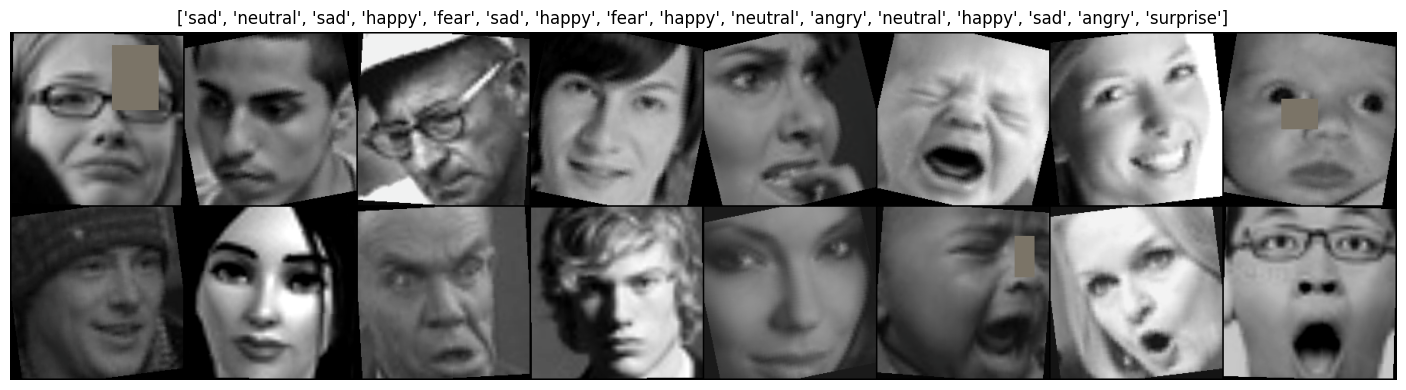

In [5]:
from torch.utils.data import random_split

class EmotionDataset(Dataset):
    def __init__(self, root: str, split: str, transform=None):
        self.root         = Path(root) / split
        self.transform    = transform
        self.classes      = CONFIG["class_names"]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = []

        for cls in self.classes:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                print(f"[WARN] Missing class folder: {cls_dir}")
                continue
            for ext in ("*.jpg", "*.jpeg", "*.png"):
                for img_path in sorted(cls_dir.glob(ext)):
                    self.samples.append((img_path, self.class_to_idx[cls]))

        if len(self.samples) == 0:
            raise RuntimeError(
                f"[ERROR] No images found under {self.root}.\n"
                f"Check that class folders exist and contain .jpg/.png files."
            )
        print(f"[INFO] {split:5s}  →  {len(self.samples):>6,} samples  |  {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

def get_transforms(split: str) -> transforms.Compose:
    img_size = CONFIG["img_size"]
    if split == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 20, img_size + 20)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(IMG_MEAN, IMG_STD),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMG_MEAN, IMG_STD),
        ])


def build_dataloaders(val_split: float = 0.15) -> dict:
   
    full_train_ds = EmotionDataset(
        root      = CONFIG["data_root"],
        split     = "train",
        transform = get_transforms("train"),
    )

    # Compute split sizes
    val_size   = int(len(full_train_ds) * val_split)
    train_size = len(full_train_ds) - val_size

    train_ds, val_ds = random_split(
        full_train_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED),
    )

    class TransformSubset(Dataset):
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform

        def __len__(self):
            return len(self.subset)

        def __getitem__(self, idx):
            img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, label

    val_ds_clean = TransformSubset(val_ds, get_transforms("val"))

    test_ds = EmotionDataset(
        root      = CONFIG["data_root"],
        split     = "test",
        transform = get_transforms("val"),
    )

    print(f"\n[INFO] Split summary:")
    print(f"         train : {train_size:>6,} samples")
    print(f"         val   : {val_size:>6,} samples")
    print(f"         test  : {len(test_ds):>6,} samples")

    loaders = {
        "train": DataLoader(
            train_ds,
            batch_size  = CONFIG["batch_size"],
            shuffle     = True,
            num_workers = 2,
            pin_memory  = (DEVICE.type == "cuda"),
            drop_last   = True,
        ),
        "val": DataLoader(
            val_ds_clean,
            batch_size  = CONFIG["batch_size"],
            shuffle     = False,
            num_workers = 2,
            pin_memory  = (DEVICE.type == "cuda"),
        ),
        "test": DataLoader(
            test_ds,
            batch_size  = CONFIG["batch_size"],
            shuffle     = False,
            num_workers = 2,
            pin_memory  = (DEVICE.type == "cuda"),
        ),
    }
    return loaders


def compute_class_weights(loader: DataLoader) -> torch.Tensor:
    counts = torch.zeros(CONFIG["num_classes"])
    for _, labels in loader:
        for lbl in labels:
            counts[lbl] += 1
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * CONFIG["num_classes"]
    print(f"\n[INFO] Class weights: {weights.numpy().round(3)}")
    return weights.to(DEVICE)


def visualize_batch(loader: DataLoader, n: int = 16):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    mean = torch.tensor(IMG_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMG_STD).view(3, 1, 1)
    imgs = (images * std + mean).clamp(0, 1)

    grid = make_grid(imgs, nrow=8, padding=2)
    plt.figure(figsize=(16, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title([CONFIG["class_names"][l] for l in labels.tolist()])
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/sample_batch.png", dpi=150)
    plt.show()


loaders       = build_dataloaders(val_split=0.15)
class_weights = compute_class_weights(loaders["train"])
visualize_batch(loaders["train"])

In [7]:
class EmotionCNN(nn.Module):

    def __init__(
        self,
        backbone_name : str   = "efficientnet_b0",
        num_classes   : int   = 7,
        dropout       : float = 0.4,
        pretrained    : bool  = True,
    ):
        super().__init__()
        self.backbone_name = backbone_name
        weights = "IMAGENET1K_V1" if pretrained else None

        # ── Backbone ──────────────────────────────────────────
        if backbone_name == "efficientnet_b0":
            base        = models.efficientnet_b0(weights=weights)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()

        elif backbone_name == "mobilenet_v3_large":
            base        = models.mobilenet_v3_large(weights=weights)
            in_features = base.classifier[0].in_features
            base.classifier = nn.Identity()

        elif backbone_name == "resnet50":
            base        = models.resnet50(weights=weights)
            in_features = base.fc.in_features
            base.fc     = nn.Identity()

        elif backbone_name == "resnet18":
            base        = models.resnet18(weights=weights)
            in_features = base.fc.in_features
            base.fc     = nn.Identity()

        else:
            raise ValueError(
                f"Unsupported backbone: {backbone_name}. "
                "Choose: efficientnet_b0 | mobilenet_v3_large | resnet50 | resnet18"
            )

        self.backbone = base

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )

        self._init_head()
        self.freeze_backbone()   # start frozen

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print("[INFO] Backbone frozen → training head only.")

    def unfreeze_backbone(self, num_layers: int = -1):
        if num_layers == -1:
            for p in self.backbone.parameters():
                p.requires_grad = True
            print("[INFO] Entire backbone unfrozen → full fine-tuning.")
        else:
            children = list(self.backbone.named_children())
            for name, child in children[-num_layers:]:
                for p in child.parameters():
                    p.requires_grad = True
                print(f"[INFO] Unfrozen layer: {name}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        return self.head(features)

    def summary(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"[INFO] Total params    : {total:>10,}")
        print(f"[INFO] Trainable params: {trainable:>10,}  ({100*trainable/total:.1f}%)")


model = EmotionCNN(
    backbone_name = CONFIG["backbone"],
    num_classes   = CONFIG["num_classes"],
    dropout       = CONFIG["dropout"],
    pretrained    = True,
).to(DEVICE)

model.summary()

criterion = nn.CrossEntropyLoss(
    weight          = class_weights,
    label_smoothing = CONFIG["label_smoothing"],
)
print("[INFO] Loss: CrossEntropyLoss (class-weighted + label smoothing)")

[INFO] Backbone frozen → training head only.
[INFO] Total params    :  4,670,595
[INFO] Trainable params:    663,047  (14.2%)
[INFO] Loss: CrossEntropyLoss (class-weighted + label smoothing)



  STAGE 1 — Head only  (5 epochs)
  [train] step    0/381  loss: 3.0469  acc: 0.078
  [train] step   50/381  loss: 3.1558  acc: 0.047
  [train] step  100/381  loss: 2.9650  acc: 0.109
  [train] step  150/381  loss: 2.7454  acc: 0.234
  [train] step  200/381  loss: 2.6939  acc: 0.172
  [train] step  250/381  loss: 2.9196  acc: 0.219
  [train] step  300/381  loss: 2.4618  acc: 0.266
  [train] step  350/381  loss: 3.0450  acc: 0.141

[S1 | Epoch 01/5]  train_loss: 2.8773  train_acc: 0.1716  |  val_loss: 2.3394  val_acc: 0.2522  (112.6s)
  ✓ Best val_acc: 0.2522 → checkpoint saved
  [train] step    0/381  loss: 2.5733  acc: 0.172
  [train] step   50/381  loss: 2.7953  acc: 0.250
  [train] step  100/381  loss: 2.7994  acc: 0.188
  [train] step  150/381  loss: 2.7111  acc: 0.203
  [train] step  200/381  loss: 2.2030  acc: 0.281
  [train] step  250/381  loss: 2.5439  acc: 0.203
  [train] step  300/381  loss: 2.5704  acc: 0.172
  [train] step  350/381  loss: 2.5967  acc: 0.219

[S1 | Epoch 02

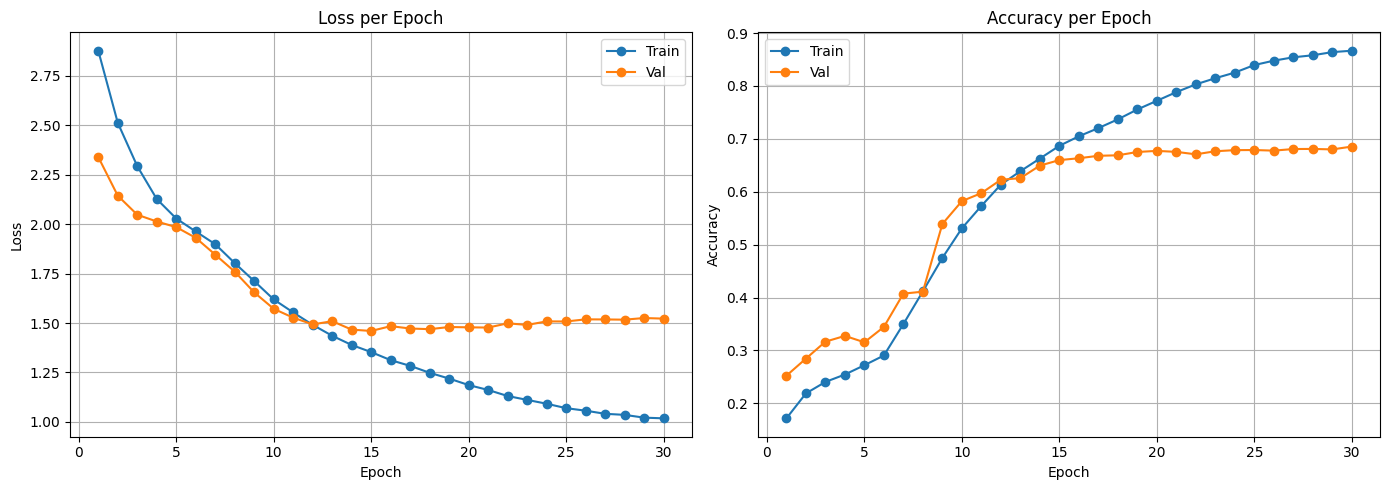

[INFO] Training curves saved → /kaggle/working/training_curves.png


In [8]:
from torch.cuda.amp import GradScaler, autocast

def build_optimizer(model: EmotionCNN, stage: int) -> optim.Optimizer:
    if stage == 1:
        return optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr           = CONFIG["lr_head"],
            weight_decay = CONFIG["weight_decay"],
        )
    else:
        return optim.AdamW([
            {"params": model.backbone.parameters(), "lr": CONFIG["lr_backbone"]},
            {"params": model.head.parameters(),     "lr": CONFIG["lr_head"]},
        ], weight_decay=CONFIG["weight_decay"])


def build_scheduler(optimizer: optim.Optimizer, steps_per_epoch: int):
    return optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr          = [g["lr"] for g in optimizer.param_groups],
        steps_per_epoch = steps_per_epoch,
        epochs          = CONFIG["num_epochs"],
        pct_start       = 0.2,
        anneal_strategy = "cos",
    )


class MetricsTracker:
    def __init__(self):
        self.history = {
            "train_loss": [], "val_loss": [],
            "train_acc" : [], "val_acc" : [],
        }

    def update(self, phase: str, loss: float, acc: float):
        self.history[f"{phase}_loss"].append(loss)
        self.history[f"{phase}_acc"].append(acc)

    def plot(self):
        epochs = range(1, len(self.history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(epochs, self.history["train_loss"], label="Train", marker="o")
        axes[0].plot(epochs, self.history["val_loss"],   label="Val",   marker="o")
        axes[0].set_title("Loss per Epoch")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].legend(); axes[0].grid(True)

        axes[1].plot(epochs, self.history["train_acc"], label="Train", marker="o")
        axes[1].plot(epochs, self.history["val_acc"],   label="Val",   marker="o")
        axes[1].set_title("Accuracy per Epoch")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
        axes[1].legend(); axes[1].grid(True)

        plt.tight_layout()
        plt.savefig("/kaggle/working/training_curves.png", dpi=150)
        plt.show()
        print("[INFO] Training curves saved → /kaggle/working/training_curves.png")


def run_epoch(
    model     : EmotionCNN,
    loader    : DataLoader,
    criterion : nn.Module,
    optimizer,
    scheduler,
    scaler,
    phase     : str,
) -> tuple:

    is_train = (phase == "train")
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=(scaler is not None)):
                logits = model(images)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

                if scheduler:
                    scheduler.step()

            running_loss += loss.item() * images.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += images.size(0)

            if is_train and batch_idx % 50 == 0:
                batch_acc = (preds == labels).float().mean().item()
                print(f"  [{phase}] step {batch_idx:>4}/{len(loader)}  "
                      f"loss: {loss.item():.4f}  acc: {batch_acc:.3f}")

    return running_loss / total, correct / total


def train(model: EmotionCNN, loaders: dict) -> MetricsTracker:

    tracker      = MetricsTracker()
    best_val_acc = 0.0
    patience_ctr = 0
    scaler       = GradScaler() if DEVICE.type == "cuda" else None

  
    STAGE1_EPOCHS = min(5, CONFIG["num_epochs"])
    print("\n" + "="*60)
    print(f"  STAGE 1 — Head only  ({STAGE1_EPOCHS} epochs)")
    print("="*60)

    optimizer1 = build_optimizer(model, stage=1)
    scheduler1 = build_scheduler(optimizer1, len(loaders["train"]))

    for epoch in range(1, STAGE1_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, loaders["train"], criterion,
                                    optimizer1, scheduler1, scaler, "train")
        vl_loss, vl_acc = run_epoch(model, loaders["val"],   criterion,
                                    None, None, None, "val")

        tracker.update("train", tr_loss, tr_acc)
        tracker.update("val",   vl_loss, vl_acc)

        print(f"\n[S1 | Epoch {epoch:02d}/{STAGE1_EPOCHS}]  "
              f"train_loss: {tr_loss:.4f}  train_acc: {tr_acc:.4f}  |  "
              f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}  "
              f"({time.time()-t0:.1f}s)")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), CONFIG["best_model_path"])
            print(f"  ✓ Best val_acc: {best_val_acc:.4f} → checkpoint saved")

    
    STAGE2_EPOCHS = CONFIG["num_epochs"] - STAGE1_EPOCHS
    print("\n" + "="*60)
    print(f"  STAGE 2 — Fine-tuning  ({STAGE2_EPOCHS} epochs)")
    print("="*60)

    model.unfreeze_backbone(num_layers=3)
    model.summary()

    optimizer2 = build_optimizer(model, stage=2)
    scheduler2 = build_scheduler(optimizer2, len(loaders["train"]))

    for epoch in range(1, STAGE2_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, loaders["train"], criterion,
                                    optimizer2, scheduler2, scaler, "train")
        vl_loss, vl_acc = run_epoch(model, loaders["val"],   criterion,
                                    None, None, None, "val")

        tracker.update("train", tr_loss, tr_acc)
        tracker.update("val",   vl_loss, vl_acc)

        print(f"\n[S2 | Epoch {epoch:02d}/{STAGE2_EPOCHS}]  "
              f"train_loss: {tr_loss:.4f}  train_acc: {tr_acc:.4f}  |  "
              f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}  "
              f"({time.time()-t0:.1f}s)")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_ctr = 0
            torch.save(model.state_dict(), CONFIG["best_model_path"])
            print(f"  ✓ Best val_acc: {best_val_acc:.4f} → checkpoint saved")
        else:
            patience_ctr += 1
            print(f"  ✗ No improvement. Patience: {patience_ctr}/{CONFIG['patience']}")
            if patience_ctr >= CONFIG["patience"]:
                print("  Early stopping triggered.")
                break

    model.load_state_dict(torch.load(CONFIG["best_model_path"], map_location=DEVICE))
    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names"     : CONFIG["class_names"],
        "backbone"        : CONFIG["backbone"],
        "img_size"        : CONFIG["img_size"],
        "best_val_acc"    : best_val_acc,
    }, CONFIG["final_model_path"])

    print(f"\n[INFO] Training complete.")
    print(f"[INFO] Best val_acc     : {best_val_acc:.4f}")
    print(f"[INFO] Final model saved: {CONFIG['final_model_path']}")
    tracker.plot()
    return tracker


tracker = train(model, loaders)



  Test Accuracy: 69.43%

              precision    recall  f1-score   support

       angry       0.60      0.61      0.61       958
     disgust       0.70      0.73      0.72       111
        fear       0.59      0.51      0.55      1024
       happy       0.88      0.88      0.88      1774
     neutral       0.63      0.67      0.65      1233
         sad       0.58      0.56      0.57      1247
    surprise       0.78      0.84      0.81       831

    accuracy                           0.69      7178
   macro avg       0.68      0.69      0.68      7178
weighted avg       0.69      0.69      0.69      7178



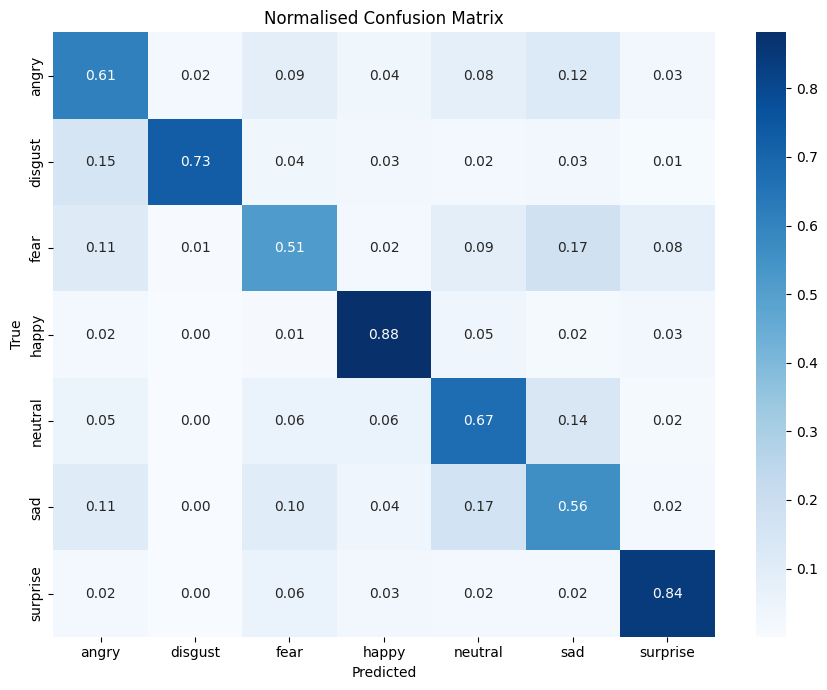

[INFO] Confusion matrix saved → /kaggle/working/confusion_matrix.png


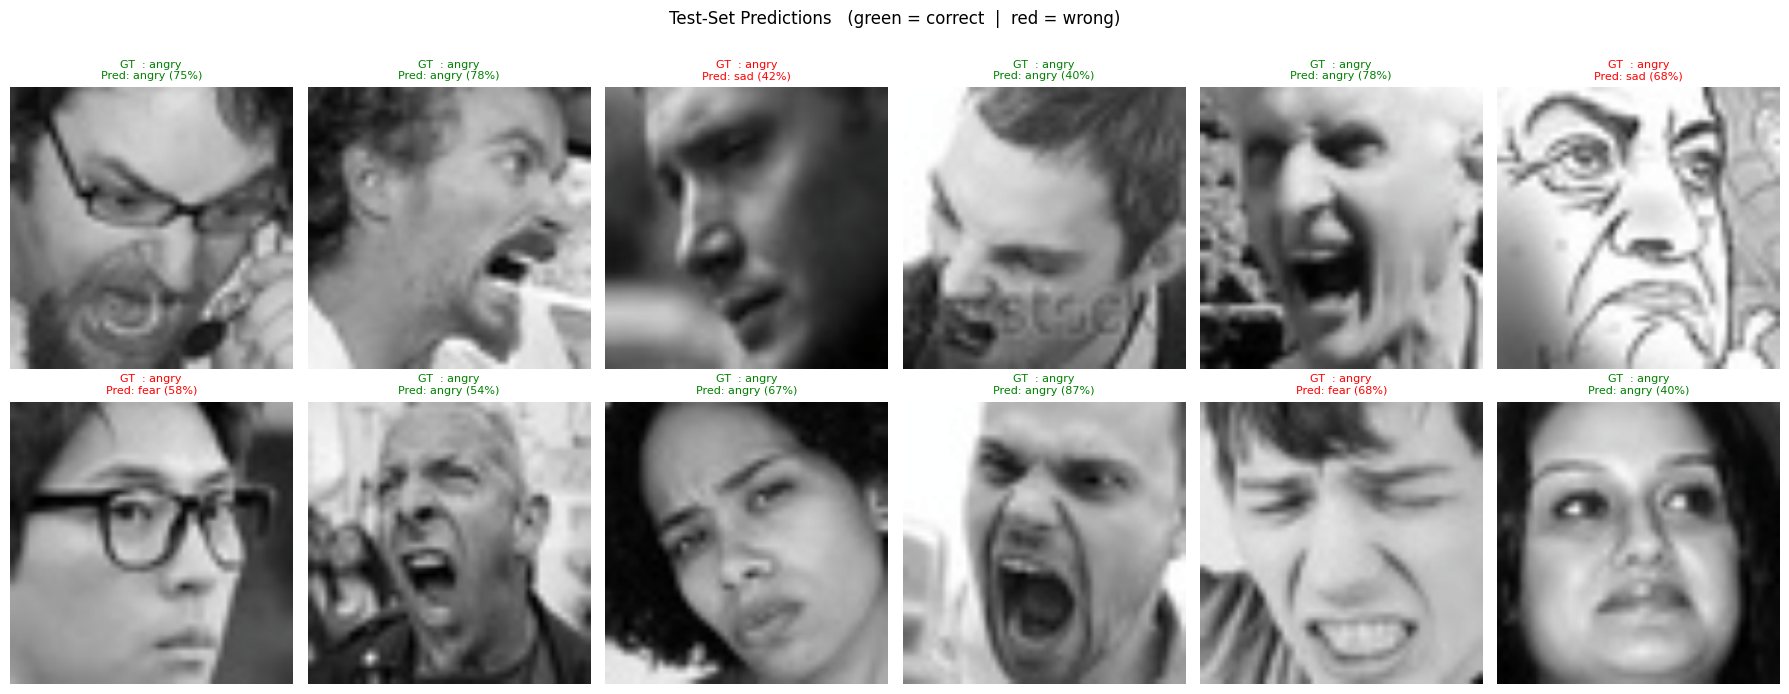

[INFO] Sample predictions saved → /kaggle/working/sample_predictions.png


In [18]:
# ============================================================
# SEGMENT 5: Evaluation on Test Set
# ============================================================

def evaluate_model(model: EmotionCNN, loader: DataLoader):
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)
            probs  = F.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    acc        = (all_preds == all_labels).mean()

    print(f"\n{'='*60}")
    print(f"  Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*60}\n")
    print(classification_report(
        all_labels, all_preds,
        target_names=CONFIG["class_names"],
    ))
    return all_preds, all_labels, all_probs


def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds, normalize="true")
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot       = True,
        fmt         = ".2f",
        cmap        = "Blues",
        xticklabels = CONFIG["class_names"],
        yticklabels = CONFIG["class_names"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalised Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
    plt.show()
    print("[INFO] Confusion matrix saved → /kaggle/working/confusion_matrix.png")


def visualize_predictions(model: EmotionCNN, loader: DataLoader, n: int = 12):
    model.eval()
    images_batch, labels_batch = next(iter(loader))
    images_gpu = images_batch[:n].to(DEVICE)

    with torch.no_grad():
        probs = F.softmax(model(images_gpu), dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)

    mean = np.array(IMG_MEAN).reshape(3, 1, 1)
    std  = np.array(IMG_STD).reshape(3, 1, 1)

    fig, axes = plt.subplots(2, 6, figsize=(18, 7))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            break
        img = images_batch[i].numpy() * std + mean
        img = np.clip(img.transpose(1, 2, 0), 0, 1)
        ax.imshow(img)

        true_lbl = CONFIG["class_names"][labels_batch[i]]
        pred_lbl = CONFIG["class_names"][preds[i]]
        conf     = probs[i][preds[i]] * 100
        color    = "green" if preds[i] == labels_batch[i] else "red"

        ax.set_title(
            f"GT  : {true_lbl}\nPred: {pred_lbl} ({conf:.0f}%)",
            color=color, fontsize=8,
        )
        ax.axis("off")

    plt.suptitle("Test-Set Predictions   (green = correct  |  red = wrong)", y=1.01)
    plt.tight_layout()
    plt.savefig("/kaggle/working/sample_predictions.png", dpi=150)
    plt.show()
    print("[INFO] Sample predictions saved → /kaggle/working/sample_predictions.png")


# ── Run evaluation ────────────────────────────────────────────
preds, labels, probs = evaluate_model(model, loaders["test"])
plot_confusion_matrix(labels, preds)
visualize_predictions(model, loaders["test"])

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms, models
import torch.nn as nn
import cv2
from IPython.display import display, HTML
import ipywidgets as widgets
import io
import warnings
warnings.filterwarnings('ignore')

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH  = "/kaggle/working/emotion_model_final.pth"
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

EMOTION_COLORS = {
    "angry"   : "#FF3B30",
    "disgust" : "#34C759",
    "fear"    : "#AF52DE",
    "happy"   : "#FFD60A",
    "neutral" : "#8E8E93",
    "sad"     : "#5E9BF0",
    "surprise": "#FF9F0A",
}

EMOTION_EMOJI = {
    "angry"   : "😠",
    "disgust" : "🤢",
    "fear"    : "😨",
    "happy"   : "😄",
    "neutral" : "😐",
    "sad"     : "😢",
    "surprise": "😲",
}

print(f"[INFO] Device : {DEVICE}")
print(f"[INFO] Classes: {CLASS_NAMES}")



class EmotionCNN(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=7, dropout=0.4):
        super().__init__()
        if backbone_name == "efficientnet_b0":
            base        = models.efficientnet_b0(weights=None)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
        elif backbone_name == "mobilenet_v3_large":
            base        = models.mobilenet_v3_large(weights=None)
            in_features = base.classifier[0].in_features
            base.classifier = nn.Identity()
        elif backbone_name == "resnet50":
            base        = models.resnet50(weights=None)
            in_features = base.fc.in_features
            base.fc     = nn.Identity()
        elif backbone_name == "resnet18":
            base        = models.resnet18(weights=None)
            in_features = base.fc.in_features
            base.fc     = nn.Identity()
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        self.backbone = base
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features), nn.Dropout(dropout),
            nn.Linear(in_features, 512), nn.SiLU(),
            nn.BatchNorm1d(512),         nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))



def load_model(path: str) -> EmotionCNN:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"[ERROR] Model not found at: {path}\n"
            "Make sure Segment 4 (training) has been run first."
        )

    ckpt        = torch.load(path, map_location=DEVICE)
    backbone    = ckpt.get("backbone",    "efficientnet_b0")
    class_names = ckpt.get("class_names", CLASS_NAMES)
    n_cls       = len(class_names)
    val_acc     = ckpt.get("best_val_acc", 0.0)

    m = EmotionCNN(backbone_name=backbone, num_classes=n_cls).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()

    print(f"[INFO] ✓ Model loaded successfully")
    print(f"[INFO]   Backbone    : {backbone}")
    print(f"[INFO]   Classes     : {class_names}")
    print(f"[INFO]   Best val_acc: {val_acc:.4f}  ({val_acc*100:.2f}%)")
    return m, class_names

emotion_model, CLASS_NAMES = load_model(MODEL_PATH)



face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_faces(image_np: np.ndarray) -> list:
    gray  = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor = 1.1,
        minNeighbors= 5,
        minSize     = (40, 40),
    )
    if len(faces) == 0:
        return []
    return [(x, y, x+w, y+h) for (x, y, w, h) in faces]



PREPROCESS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

def crop_face_with_margin(image_pil: Image.Image, bbox: tuple, margin: float = 0.20) -> Image.Image:
    x1, y1, x2, y2 = bbox
    W, H = image_pil.size

    mx = int((x2 - x1) * margin)
    my = int((y2 - y1) * margin)
    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(W, x2 + mx)
    y2 = min(H, y2 + my)

    return image_pil.crop((x1, y1, x2, y2))

def preprocess_face_region(face_pil: Image.Image) -> torch.Tensor:
    return PREPROCESS(face_pil.convert("RGB")).unsqueeze(0).to(DEVICE)



def predict_emotion(tensor: torch.Tensor, temperature: float = 2.0) -> np.ndarray:
   
    with torch.no_grad():
        logits        = emotion_model(tensor)
        scaled_logits = logits / temperature
        probs         = F.softmax(scaled_logits, dim=1).squeeze().cpu().numpy()
    return probs



def visualize_result(
    original_pil : Image.Image,
    faces        : list,
    all_probs    : list,
    all_emotions : list,
):
    
    n_faces = len(faces)
    if n_faces == 0:
        print("[WARN] No faces detected — showing original image.")
        plt.figure(figsize=(6, 6))
        plt.imshow(original_pil)
        plt.axis("off")
        plt.title("No face detected", fontsize=14, color="red")
        plt.show()
        return

    fig = plt.figure(figsize=(7 + 5 * n_faces, 6))
    gs  = fig.add_gridspec(1, 1 + n_faces, wspace=0.35)

    ax_img = fig.add_subplot(gs[0, 0])
    img_draw = np.array(original_pil).copy()

    for i, (bbox, emotion, probs) in enumerate(zip(faces, all_emotions, all_probs)):
        x1, y1, x2, y2 = bbox
        hex_color = EMOTION_COLORS.get(emotion, "#FFFFFF")
        rgb       = tuple(int(hex_color.lstrip("#")[j:j+2], 16) for j in (0, 2, 4))
        bgr       = (rgb[2], rgb[1], rgb[0])

        # Box
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), bgr, 3)

        # Label background + text
        conf      = probs.max() * 100
        label     = f"{EMOTION_EMOJI.get(emotion, '')} {emotion.upper()} {conf:.0f}%"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        label_y   = max(y1 - 10, th + 10)

        cv2.rectangle(img_draw,
                      (x1, label_y - th - bl - 4),
                      (x1 + tw + 6, label_y + bl),
                      bgr, -1)
        cv2.putText(img_draw, label, (x1 + 3, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 2, cv2.LINE_AA)

        if n_faces > 1:
            cv2.putText(img_draw, f"#{i+1}", (x1 + 5, y1 + 22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    ax_img.imshow(img_draw)
    ax_img.set_title("Detected Face(s)", fontsize=13, fontweight="bold", pad=10)
    ax_img.axis("off")

    # ── Right panels: bar charts per face ─────────────────────
    for i, (probs, emotion) in enumerate(zip(all_probs, all_emotions)):
        ax = fig.add_subplot(gs[0, i + 1])

        sorted_idx    = np.argsort(probs)[::-1]
        sorted_names  = [CLASS_NAMES[j] for j in sorted_idx]
        sorted_probs  = [probs[j]       for j in sorted_idx]
        bar_colors    = [EMOTION_COLORS.get(n, "#AAAAAA") for n in sorted_names]

        bars = ax.barh(
            range(len(CLASS_NAMES)),
            sorted_probs,
            color  = bar_colors,
            edgecolor = "white",
            linewidth = 0.5,
            height = 0.65,
        )

        for bar, prob in zip(bars, sorted_probs):
            ax.text(
                min(prob + 0.01, 0.95),
                bar.get_y() + bar.get_height() / 2,
                f"{prob*100:.1f}%",
                va="center", ha="left",
                fontsize=9, fontweight="bold",
                color="white" if prob > 0.15 else "black",
            )

        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_yticklabels(
            [f"{EMOTION_EMOJI.get(n,'')} {n}" for n in sorted_names],
            fontsize=10,
        )
        ax.set_xlim(0, 1.15)
        ax.set_xlabel("Confidence", fontsize=10)
        ax.invert_yaxis()

        face_title = f"Face #{i+1} — " if n_faces > 1 else ""
        ax.set_title(
            f"{face_title}{EMOTION_EMOJI.get(emotion,'')} {emotion.upper()}",
            fontsize=13, fontweight="bold",
            color=EMOTION_COLORS.get(emotion, "#000000"), pad=10,
        )
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        ax.spines[["top","right"]].set_visible(False)

    plt.suptitle("Facial Emotion Recognition Result",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.savefig("/kaggle/working/emotion_result.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Result saved → /kaggle/working/emotion_result.png")



def run_emotion_detection(image_path: str, temperature: float = 2.0):
    print(f"\n{'='*55}")
    print(f"  Processing: {os.path.basename(image_path)}")
    print(f"{'='*55}")

    # ── Load image ────────────────────────────────────────────
    try:
        image_pil = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"[ERROR] Cannot open image: {e}")
        return

    image_np  = np.array(image_pil)
    W, H      = image_pil.size
    print(f"[INFO] Image size: {W} x {H} px")

    # ── Detect faces ──────────────────────────────────────────
    faces = detect_faces(image_np)
    print(f"[INFO] Faces detected: {len(faces)}")

    if len(faces) == 0:
        print("[WARN] No face found. Tips:")
        print("         • Ensure good lighting")
        print("         • Face the camera directly")
        print("         • Image should be at least 100x100 px")
        visualize_result(image_pil, [], [], [])
        return

    # ── Per-face inference ────────────────────────────────────
    all_probs    = []
    all_emotions = []

    for i, bbox in enumerate(faces):
        face_crop = crop_face_with_margin(image_pil, bbox, margin=0.20)
        tensor    = preprocess_face_region(face_crop)
        probs     = predict_emotion(tensor, temperature=temperature)
        emotion   = CLASS_NAMES[np.argmax(probs)]
        confidence= probs.max() * 100

        all_probs.append(probs)
        all_emotions.append(emotion)

        print(f"\n  Face #{i+1}:")
        print(f"    Predicted : {EMOTION_EMOJI.get(emotion,'')} {emotion.upper()}  ({confidence:.1f}%)")
        print(f"    All scores:")
        sorted_idx = np.argsort(probs)[::-1]
        for j in sorted_idx:
            bar = "█" * int(probs[j] * 30)
            print(f"      {CLASS_NAMES[j]:>10s}: {bar:<30s} {probs[j]*100:5.1f}%")

    visualize_result(image_pil, faces, all_probs, all_emotions)



print("\n" + "="*55)
print("  FACIAL EMOTION DETECTOR — Upload Your Image Below")
print("="*55)
print("Supported formats: JPG, JPEG, PNG")
print("Tips for best results:")
print("  • Face the camera directly (frontal view)")
print("  • Good lighting — avoid shadows on face")
print("  • Single face per image recommended")
print("  • Minimum image size: 100 x 100 px\n")

# Temperature slider
temp_slider = widgets.FloatSlider(
    value       = 2.0,
    min         = 1.0,
    max         = 4.0,
    step        = 0.1,
    description = "Temperature:",
    tooltip     = "Higher = softer predictions. Tune if one emotion dominates.",
    style       = {"description_width": "initial"},
    layout      = widgets.Layout(width="400px"),
)

uploader = widgets.FileUpload(
    accept   = "image/*",
    multiple = False,
    description = "Upload Image",
    button_style= "primary",
    layout   = widgets.Layout(width="200px"),
)

run_btn = widgets.Button(
    description  = "▶  Detect Emotion",
    button_style = "success",
    layout       = widgets.Layout(width="200px", height="40px"),
)

output = widgets.Output()

def on_run_clicked(b):
    output.clear_output()
    with output:
        if not uploader.value:
            print("[ERROR] Please upload an image first.")
            return

        try:
            if isinstance(uploader.value, tuple):
                file_info    = uploader.value[0]
                file_content = file_info["content"]

            elif isinstance(uploader.value, dict):
                upload_key   = list(uploader.value.keys())[0]
                file_info    = uploader.value[upload_key]
                file_content = file_info["content"]

            else:
                print(f"[ERROR] Unexpected uploader format: {type(uploader.value)}")
                return

            # content may be bytes or memoryview — normalize to bytes
            if isinstance(file_content, memoryview):
                file_content = bytes(file_content)

        except Exception as e:
            print(f"[ERROR] Could not read uploaded file: {e}")
            return

        save_path = "/kaggle/working/uploaded_face.jpg"
        with open(save_path, "wb") as f:
            f.write(file_content)

        print(f"[INFO] File saved ({len(file_content)/1024:.1f} KB)")
        run_emotion_detection(save_path, temperature=temp_slider.value)


run_btn.on_click(on_run_clicked)

display(widgets.VBox([
    widgets.HBox([uploader, run_btn]),
    temp_slider,
    output,
]))

[INFO] Device : cuda
[INFO] Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
[INFO] ✓ Model loaded successfully
[INFO]   Backbone    : efficientnet_b0
[INFO]   Classes     : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
[INFO]   Best val_acc: 0.6853  (68.53%)

  FACIAL EMOTION DETECTOR — Upload Your Image Below
Supported formats: JPG, JPEG, PNG
Tips for best results:
  • Face the camera directly (frontal view)
  • Good lighting — avoid shadows on face
  • Single face per image recommended
  • Minimum image size: 100 x 100 px

